Decision Tree

In [3]:
import os
import glob
import pandas as pd
import numpy as np

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DIR = "/content/drive/My Drive/Colab Notebooks/data/"
os.chdir(DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
os.chdir(DIR)
!ls

 699.csv	      ioc_feed.xml	    superstore_json.json
'alerts (1).json'     netflow.jsonl	    superstore_tsv.tsv
 alerts.json	      security_policy.yml   superstore.txt
 auth_logs.csv	      soc_alerts.xlsx	    superstore_xls.xlsx
 car_dataset.csv      soc_dump.sql	    Titanic_Dataset.csv
 dns_queries.tsv      superstore.csv	    unclean_data.csv
 incident_notes.txt   superstore.dbf	    web_access.log


In [ ]:
datafile1='PlayTennis.csv'
filename1 = DIR+'/'+datafile1 # csv file
df= pd.read_csv(filename1)
df

,Outlook,Temperature,Humidity,Wind,PlayTennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [ ]:
t = df.keys()[-1]
print('Target Attribute is: ', t)
# Get the attribute names from input dataset
attribute_names = list(df.keys())
#Remove the target attribute from the attribute names list
attribute_names.remove(t)
print('Predicting Attributes: ', attribute_names)

Target Attribute is:  PlayTennis
Predicting Attributes:  ['Outlook', 'Temperature', 'Humidity', 'Wind']


In [ ]:
#Function to calculate the entropy of collection S
import math
def entropy(probs):
    return sum( [-prob*math.log(prob, 2) for prob in probs])

#Function to calulate the entropy of the given Data Sets/List with
#respect to target attributes
def entropy_of_list(ls,value):
    from collections import Counter
    cnt = Counter(x for x in ls)# Counter calculates the propotion of class
    print('Target attribute class count(Yes/No)=',dict(cnt))
    total_instances = len(ls)
    print("Total no of instances/records associated with {0} is: {1}".format(value,total_instances ))
    probs = [x / total_instances for x in cnt.values()]  # x means no of YES/NO
    print("Probability of Class {0} is: {1:.4f}".format(min(cnt),min(probs)))
    print("Probability of Class {0} is: {1:.4f}".format(max(cnt),max(probs)))
    return entropy(probs) # Call Entropy

In [ ]:
def information_gain(df, split_attribute, target_attribute,battr):
    print("\n\n-----Information Gain Calculation of ",split_attribute, " --------")
    df_split = df.groupby(split_attribute) # group the data based on attribute values
    glist=[]
    for gname,group in df_split:
        print('Grouped Attribute Values \n',group)
        glist.append(gname)

    glist.reverse()
    nobs = len(df.index) * 1.0
    df_agg1=df_split.agg({target_attribute:lambda x:entropy_of_list(x, glist.pop())})
    df_agg2=df_split.agg({target_attribute :lambda x:len(x)/nobs})

    df_agg1.columns=['Entropy']
    df_agg2.columns=['Proportion']

    # Calculate Information Gain:
    new_entropy = sum( df_agg1['Entropy'] * df_agg2['Proportion'])
    if battr !='S':
        old_entropy = entropy_of_list(df[target_attribute],'S-'+df.iloc[0][df.columns.get_loc(battr)])
    else:
        old_entropy = entropy_of_list(df[target_attribute],battr)
    return old_entropy - new_entropy

In [ ]:
def id3(df, target_attribute, attribute_names, default_class=None,default_attr='S'):

    from collections import Counter
    cnt = Counter(x for x in df[target_attribute])# class of YES /NO

    ## First check: Is this split of the dataset homogeneous?
    if len(cnt) == 1:
        return next(iter(cnt))  # next input data set, or raises StopIteration when EOF is hit.

    ## Second check: Is this split of the dataset empty? if yes, return a default value
    elif df.empty or (not attribute_names):
        return default_class  # Return None for Empty Data Set

    ## Otherwise: This dataset is ready to be devied up!
    else:
        # Get Default Value for next recursive call of this function:
        default_class = max(cnt.keys()) #No of YES and NO Class
        # Compute the Information Gain of the attributes:
        gainz=[]
        for attr in attribute_names:
            ig= information_gain(df, attr, target_attribute,default_attr)
            gainz.append(ig)
            print('Information gain of ',attr,' is : ',ig)

        index_of_max = gainz.index(max(gainz))               # Index of Best Attribute
        best_attr = attribute_names[index_of_max]            # Choose Best Attribute to split on
        print("\nAttribute with the maximum gain is: ", best_attr)
        # Create an empty tree, to be populated in a moment
        tree = {best_attr:{}} # Initiate the tree with best attribute as a node
        remaining_attribute_names =[i for i in attribute_names if i != best_attr]

        # Split dataset-On each split, recursively call this algorithm.Populate the empty tree with subtrees, which
        # are the result of the recursive call
        for attr_val, data_subset in df.groupby(best_attr):
            subtree = id3(data_subset,target_attribute, remaining_attribute_names,default_class,best_attr)
            tree[best_attr][attr_val] = subtree
        return tree

In [ ]:
from pprint import pprint
tree = id3(df,t,attribute_names)
print("\nThe Resultant Decision Tree is:")
pprint(tree)



-----Information Gain Calculation of  Outlook  --------
Grouped Attribute Values 
      Outlook Temperature Humidity    Wind PlayTennis
2   Overcast         Hot     High    Weak        Yes
6   Overcast        Cool   Normal  Strong        Yes
11  Overcast        Mild     High  Strong        Yes
12  Overcast         Hot   Normal    Weak        Yes
Grouped Attribute Values 
    Outlook Temperature Humidity    Wind PlayTennis
3     Rain        Mild     High    Weak        Yes
4     Rain        Cool   Normal    Weak        Yes
5     Rain        Cool   Normal  Strong         No
9     Rain        Mild   Normal    Weak        Yes
13    Rain        Mild     High  Strong         No
Grouped Attribute Values 
    Outlook Temperature Humidity    Wind PlayTennis
0    Sunny         Hot     High    Weak         No
1    Sunny         Hot     High  Strong         No
7    Sunny        Mild     High    Weak         No
8    Sunny        Cool   Normal    Weak        Yes
10   Sunny        Mild   Normal  St

/tmp/ipykernel_9198/1613919912.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  old_entropy = entropy_of_list(df[target_attribute],'S-'+df.iloc[0][df.columns.get_loc(battr)])
/tmp/ipykernel_9198/1613919912.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  old_entropy = entropy_of_list(df[target_attribute],'S-'+df.iloc[0][df.columns.get_loc(battr)])
/tmp/ipykernel_9198/1613919912.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[po

In [ ]:
def classify(instance, tree,default=None): # Instance of Play Tennis with Predicted
    attribute = next(iter(tree)) # Outlook/Humidity/Wind
    if instance[attribute] in tree[attribute].keys(): # Value of the attributs in  set of Tree keys
        result = tree[attribute][instance[attribute]]
        if isinstance(result, dict): # this is a tree, delve deeper
            return classify(instance, result)
        else:
            return result # this is a label
    else:
        return default

In [ ]:
df_new=pd.read_csv('PlayTennisTest.csv')
df_new['predicted'] = df_new.apply(classify, axis=1, args=(tree,'?'))
print(df_new)

  Outlook Temperature Humidity    Wind PlayTennis predicted
0   Sunny         Hot   Normal    Weak          ?       Yes
1    Rain        Mild     High  Strong          ?        No


In [ ]:
!pip install graphviz

In [ ]:
from graphviz import Digraph

def add_nodes_edges(tree, dot=None, parent=None, edge_label=""):
    if dot is None:
        dot = Digraph()
        dot.attr("node", shape="box")

    if isinstance(tree, dict):
        for root, branches in tree.items():
            node_id = str(id(branches)) + root
            dot.node(node_id, root)

            if parent is not None:
                dot.edge(parent, node_id, label=edge_label)

            for branch_value, subtree in branches.items():
                add_nodes_edges(subtree, dot, node_id, str(branch_value))
    else:
        leaf_id = str(id(tree)) + str(tree)
        dot.node(leaf_id, str(tree), shape="ellipse")
        if parent is not None:
            dot.edge(parent, leaf_id, label=edge_label)

    return dot

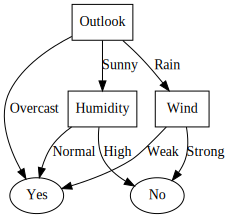

In [ ]:
dot = add_nodes_edges(tree)
dot